Test Accuracy: 98.74%
The final training accuracy is 98.67%.





In [ ]:
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 74.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import time

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [ ]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import time

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModel
)

device = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)

print("PyTorch:", torch.__version__)
print("Transformers imported successfully!")
print("Device:", device)

PyTorch: 2.11.0+cu128
Transformers imported successfully!
Device: cuda


In [ ]:
data=pd.read_csv('/content/spam.csv', encoding='latin1')

In [ ]:
data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
data.columns = ['label', 'message']

In [ ]:
# Dataset Size
print(
    "Total SMS messages:",
    len(data)
)

print(
    "Dataset shape:",
    data.shape
)

Total SMS messages: 5572
Dataset shape: (5572, 2)


In [ ]:
data = data.dropna(
    subset=["message", "label"]
).reset_index(drop=True)

In [ ]:
#SMS Character Length
data["char_length"] = data[
    "message"
].apply(len)

print(
    "Minimum SMS length:",
    data["char_length"].min()
)

print(
    "Maximum SMS length:",
    data["char_length"].max()
)

print(
    "Average SMS length:",
    data["char_length"].mean()
)

Minimum SMS length: 2
Maximum SMS length: 910
Average SMS length: 80.11880832735105


In [ ]:
# Average Number of Words
data["word_count"] = data[
    "message"
].apply(
    lambda x: len(x.split())
)

print(
    "Average words per SMS:",
    data["word_count"].mean()
)

Average words per SMS: 15.494436468054559


In [ ]:

# Text Preprocessing
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = text.strip()

    return text

In [ ]:
data["clean_message"] = data[
    "message"
].apply(clean_text)

In [ ]:
data["label_num"] = data[
    "label"
].map({
    "ham": 0,
    "spam": 1
})

data[
    ["label", "label_num"]
].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [ ]:
print(
    "Duplicate messages:",
    data["clean_message"].duplicated().sum()
)

Duplicate messages: 415


In [ ]:
data = data.drop_duplicates(
    subset=["clean_message"]
).reset_index(drop=True)

print(
    "Dataset size:",
    len(data)
)

Dataset size: 5157


In [ ]:
X = data[
    "clean_message"
].values

y = data[
    "label_num"
].values

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (5157,)
y shape: (5157,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 4125
Testing samples: 1032


In [ ]:
MINILM_NAME = (
    "microsoft/MiniLM-L12-H384-uncased"
)

ROBERTA_NAME = (
    "FacebookAI/roberta-base"
)

MAX_LEN = 128

BATCH_SIZE = 4

EPOCHS = 3

LEARNING_RATE = 2e-5

DROPOUT = 0.30

DENSE_HIDDEN = 128

print("MiniLM:", MINILM_NAME)
print("RoBERTa:", ROBERTA_NAME)

print("Maximum length:", MAX_LEN)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Dropout:", DROPOUT)

MiniLM: microsoft/MiniLM-L12-H384-uncased
RoBERTa: FacebookAI/roberta-base
Maximum length: 128
Batch size: 4
Epochs: 3
Learning rate: 2e-05
Dropout: 0.3


In [ ]:
minilm_tokenizer = AutoTokenizer.from_pretrained(
    MINILM_NAME
)

roberta_tokenizer = AutoTokenizer.from_pretrained(
    ROBERTA_NAME
)

print(
    "MiniLM tokenizer loaded."
)

print(
    "RoBERTa tokenizer loaded."
)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

MiniLM tokenizer loaded.
RoBERTa tokenizer loaded.


In [ ]:
minilm_test = AutoModel.from_pretrained(
    MINILM_NAME
)

print(
    "MiniLM loaded successfully!"
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  133MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MiniLM loaded successfully!


In [ ]:
roberta_test = AutoModel.from_pretrained(
    ROBERTA_NAME
)

print(
    "RoBERTa loaded successfully!"
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  133MB            

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa loaded successfully!


In [ ]:
sample_sms = X_train[0]

print("Original SMS:")
print(sample_sms)

print("\nMiniLM Tokens:")
print(
    minilm_tokenizer.tokenize(
        sample_sms
    )
)

print("\nRoBERTa Tokens:")
print(
    roberta_tokenizer.tokenize(
        sample_sms
    )
)

Original SMS:
haha okay... today weekend leh...

MiniLM Tokens:
['ha', '##ha', 'okay', '.', '.', '.', 'today', 'weekend', 'le', '##h', '.', '.', '.']

RoBERTa Tokens:
['h', 'aha', 'Ġokay', '...', 'Ġtoday', 'Ġweekend', 'Ġle', 'h', '...']


In [ ]:
class MiniLM_RoBERTa_Dataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        minilm_tokenizer,
        roberta_tokenizer,
        max_len
    ):

        self.texts = texts
        self.labels = labels

        self.minilm_tokenizer = (
            minilm_tokenizer
        )

        self.roberta_tokenizer = (
            roberta_tokenizer
        )

        self.max_len = max_len

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(
            self.texts[idx]
        )

        label = self.labels[idx]

        minilm_encoding = (
            self.minilm_tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_attention_mask=True,
                return_tensors="pt"
            )
        )

        roberta_encoding = (
            self.roberta_tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_attention_mask=True,
                return_tensors="pt"
            )
        )

        return {

            "minilm_input_ids":
                minilm_encoding[
                    "input_ids"
                ].flatten(),

            "minilm_attention_mask":
                minilm_encoding[
                    "attention_mask"
                ].flatten(),

            "roberta_input_ids":
                roberta_encoding[
                    "input_ids"
                ].flatten(),

            "roberta_attention_mask":
                roberta_encoding[
                    "attention_mask"
                ].flatten(),

            "label":
                torch.tensor(
                    label,
                    dtype=torch.float
                )
        }

In [ ]:
train_dataset = MiniLM_RoBERTa_Dataset(
    X_train,
    y_train,
    minilm_tokenizer,
    roberta_tokenizer,
    MAX_LEN
)

print(
    "Training dataset created."
)

Training dataset created.


In [ ]:
test_dataset = MiniLM_RoBERTa_Dataset(
    X_test,
    y_test,
    minilm_tokenizer,
    roberta_tokenizer,
    MAX_LEN
)

print(
    "Testing dataset created."
)

Testing dataset created.


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

Training batches: 1032
Testing batches: 258


In [ ]:
batch = next(
    iter(train_loader)
)

print(
    "MiniLM input:",
    batch[
        "minilm_input_ids"
    ].shape
)

print(
    "RoBERTa input:",
    batch[
        "roberta_input_ids"
    ].shape
)

print(
    "Labels:",
    batch["label"].shape
)

MiniLM input: torch.Size([4, 128])
RoBERTa input: torch.Size([4, 128])
Labels: torch.Size([4])


In [ ]:
# Define Hybrid Model

In [ ]:
class MiniLM_RoBERTa_Hybrid(
    nn.Module
):

    def __init__(
        self,
        minilm_name,
        roberta_name,
        dense_hidden=128,
        dropout=0.30
    ):

        super(
            MiniLM_RoBERTa_Hybrid,
            self
        ).__init__()

        # =========================
        # MiniLM - SLM
        # =========================

        self.minilm = AutoModel.from_pretrained(
            minilm_name
        )

        # =========================
        # RoBERTa - Larger Transformer
        # =========================

        self.roberta = AutoModel.from_pretrained(
            roberta_name
        )

        # Hidden dimensions

        minilm_dim = (
            self.minilm.config.hidden_size
        )

        roberta_dim = (
            self.roberta.config.hidden_size
        )

        print(
            "MiniLM hidden size:",
            minilm_dim
        )

        print(
            "RoBERTa hidden size:",
            roberta_dim
        )

        # Combined feature size

        combined_dim = (
            minilm_dim
            + roberta_dim
        )

        print(
            "Combined feature size:",
            combined_dim
        )

        # =========================
        # Dropout
        # =========================

        self.dropout = nn.Dropout(
            dropout
        )

        # =========================
        # Feature Fusion Layer
        # =========================

        self.fc1 = nn.Linear(
            combined_dim,
            dense_hidden
        )

        # =========================
        # Binary Classifier
        # =========================

        self.output = nn.Linear(
            dense_hidden,
            1
        )

    def forward(
        self,

        minilm_input_ids,
        minilm_attention_mask,

        roberta_input_ids,
        roberta_attention_mask
    ):

        # =========================
        # MiniLM
        # =========================

        minilm_output = self.minilm(
            input_ids=minilm_input_ids,
            attention_mask=minilm_attention_mask
        )

        minilm_features = (
            minilm_output.last_hidden_state[
                :, 0, :
            ]
        )

        # =========================
        # RoBERTa
        # =========================

        roberta_output = self.roberta(
            input_ids=roberta_input_ids,
            attention_mask=roberta_attention_mask
        )

        roberta_features = (
            roberta_output.last_hidden_state[
                :, 0, :
            ]
        )

        # =========================
        # Feature Fusion
        # =========================

        combined_features = torch.cat(
            [
                minilm_features,
                roberta_features
            ],
            dim=1
        )

        # =========================
        # Dropout
        # =========================

        x = self.dropout(
            combined_features
        )

        # =========================
        # Dense Layer
        # =========================

        x = torch.relu(
            self.fc1(x)
        )

        x = self.dropout(x)

        # =========================
        # Output
        # =========================

        output = self.output(x)

        return output.squeeze(1)

In [ ]:
# Create Model
model = MiniLM_RoBERTa_Hybrid(
    minilm_name=MINILM_NAME,
    roberta_name=ROBERTA_NAME,
    dense_hidden=DENSE_HIDDEN,
    dropout=DROPOUT
)

model = model.to(device)

print(
    "MiniLM + RoBERTa hybrid created successfully!"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


MiniLM hidden size: 384
RoBERTa hidden size: 768
Combined feature size: 1152
MiniLM + RoBERTa hybrid created successfully!


In [ ]:
# Count Parameters
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

Total parameters: 158153345
Trainable parameters: 158153345


In [ ]:
# Loss Function
criterion = nn.BCEWithLogitsLoss()

print(
    "Loss Function: Binary Cross Entropy"
)

Loss Function: Binary Cross Entropy


In [ ]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print(
    "Optimizer: AdamW"
)

print(
    "Learning Rate:",
    LEARNING_RATE
)

Optimizer: AdamW
Learning Rate: 2e-05


In [ ]:
# Training Function
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for batch in loader:

        minilm_input_ids = batch[
            "minilm_input_ids"
        ].to(device)

        minilm_attention_mask = batch[
            "minilm_attention_mask"
        ].to(device)

        roberta_input_ids = batch[
            "roberta_input_ids"
        ].to(device)

        roberta_attention_mask = batch[
            "roberta_attention_mask"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        optimizer.zero_grad()

        outputs = model(

            minilm_input_ids,
            minilm_attention_mask,

            roberta_input_ids,
            roberta_attention_mask
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(labels)
        )

        probabilities = torch.sigmoid(
            outputs
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += len(labels)

    epoch_loss = (
        total_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy
    )

In [ ]:
# Evaluation Function
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0

    correct = 0

    total = 0

    all_labels = []

    all_predictions = []

    all_probabilities = []

    with torch.no_grad():

        for batch in loader:

            minilm_input_ids = batch[
                "minilm_input_ids"
            ].to(device)

            minilm_attention_mask = batch[
                "minilm_attention_mask"
            ].to(device)

            roberta_input_ids = batch[
                "roberta_input_ids"
            ].to(device)

            roberta_attention_mask = batch[
                "roberta_attention_mask"
            ].to(device)

            labels = batch[
                "label"
            ].to(device)

            outputs = model(

                minilm_input_ids,
                minilm_attention_mask,

                roberta_input_ids,
                roberta_attention_mask
            )

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item()
                * len(labels)
            )

            probabilities = torch.sigmoid(
                outputs
            )

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += len(labels)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    loss = (
        total_loss / total
    )

    accuracy = (
        correct / total
    )

    return (
        loss,
        accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [ ]:
from tqdm.auto import tqdm
import time

# ==============================
# Train the Hybrid Model
# ==============================

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(EPOCHS):

    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")

    # ------------------------------
    # Training
    # ------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Training Epoch {epoch + 1}/{EPOCHS}",
        unit="batch",
        dynamic_ncols=True
    )

    for batch in progress_bar:

        minilm_input_ids = batch[
            "minilm_input_ids"
        ].to(device)

        minilm_attention_mask = batch[
            "minilm_attention_mask"
        ].to(device)

        roberta_input_ids = batch[
            "roberta_input_ids"
        ].to(device)

        roberta_attention_mask = batch[
            "roberta_attention_mask"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            minilm_input_ids,
            minilm_attention_mask,
            roberta_input_ids,
            roberta_attention_mask
        )

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # ------------------------------
        # Calculate running metrics
        # ------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        probabilities = torch.sigmoid(
            outputs
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

        current_loss = (
            running_loss / total
        )

        current_accuracy = (
            correct / total
        )

        # ------------------------------
        # Update progress bar
        # ------------------------------

        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}",
            accuracy=f"{current_accuracy:.4f}"
        )

    # ------------------------------
    # Final training metrics
    # ------------------------------

    train_loss = (
        running_loss / total
    )

    train_accuracy = (
        correct / total
    )

    # ------------------------------
    # Validation
    # ------------------------------

    val_loss, val_accuracy, _, _, _ = (
        evaluate_model(
            model,
            test_loader,
            criterion,
            device
        )
    )

    # Store results
    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    # ------------------------------
    # Epoch summary
    # ------------------------------

    elapsed_time = (
        time.time() - start_time
    )

    print("\nEpoch Summary")
    print("-" * 60)

    print(
        f"Train Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Validation Loss : {val_loss:.4f}"
    )

    print(
        f"Validation Acc. : "
        f"{val_accuracy * 100:.2f}%"
    )

    print(
        f"Elapsed Time    : "
        f"{elapsed_time / 60:.2f} minutes"
    )

    print("-" * 60)


# ==============================
# Total Training Time
# ==============================

training_time = (
    time.time() - start_time
)

print("\n" + "=" * 60)

print(
    f"Total Training Time: "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Total Epochs: {EPOCHS}"
)

print("=" * 60)


Epoch 1/3


Training Epoch 1/3:   0%|          | 0/1032 [00:00<?, ?batch/s]


Epoch Summary
------------------------------------------------------------
Train Loss      : 0.0902
Train Accuracy  : 96.80%
Validation Loss : 0.0380
Validation Acc. : 99.03%
Elapsed Time    : 3.24 minutes
------------------------------------------------------------

Epoch 2/3


Training Epoch 2/3:   0%|          | 0/1032 [00:00<?, ?batch/s]


Epoch Summary
------------------------------------------------------------
Train Loss      : 0.0663
Train Accuracy  : 98.11%
Validation Loss : 0.0348
Validation Acc. : 99.13%
Elapsed Time    : 6.54 minutes
------------------------------------------------------------

Epoch 3/3


Training Epoch 3/3:   0%|          | 0/1032 [00:00<?, ?batch/s]


Epoch Summary
------------------------------------------------------------
Train Loss      : 0.0599
Train Accuracy  : 98.67%
Validation Loss : 0.0456
Validation Acc. : 98.74%
Elapsed Time    : 9.79 minutes
------------------------------------------------------------

Total Training Time: 9.79 minutes
Total Epochs: 3


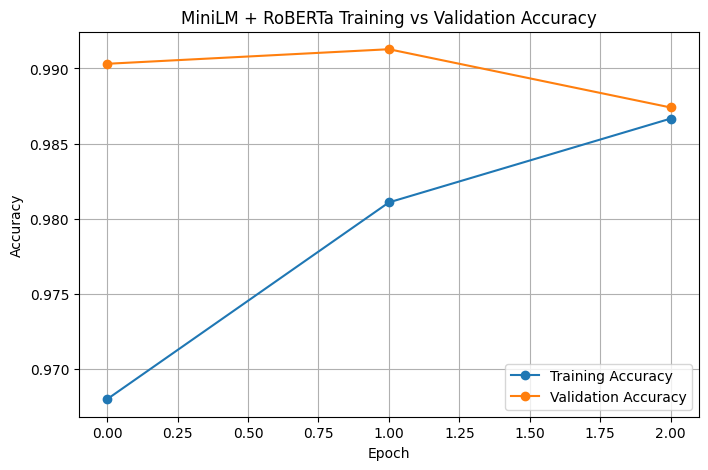

In [ ]:
# Training vs Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "MiniLM + RoBERTa Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

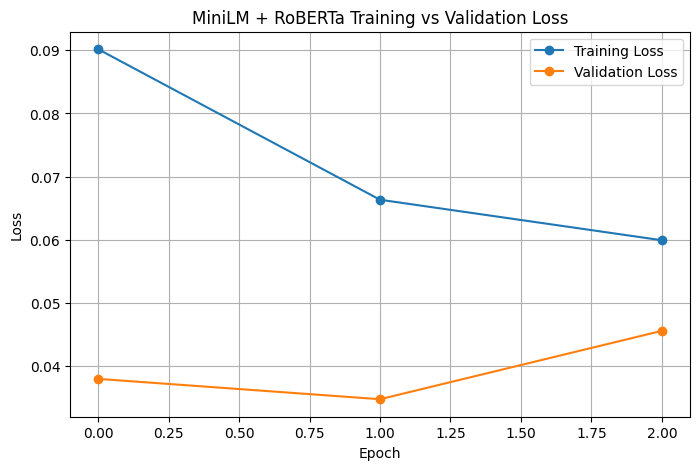

In [ ]:
# Training vs Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "MiniLM + RoBERTa Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Final Test Evaluation
test_loss, test_accuracy, y_true, y_pred, y_probability = (
    evaluate_model(
        model,
        test_loader,
        criterion,
        device
    )
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Accuracy: 98.74%


In [ ]:
# Accuracy, Precision, Recall, F1
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

Accuracy : 0.9874
Precision: 0.9600
Recall   : 0.9375
F1-score : 0.9486


In [ ]:
# Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[899   5]
 [  8 120]]


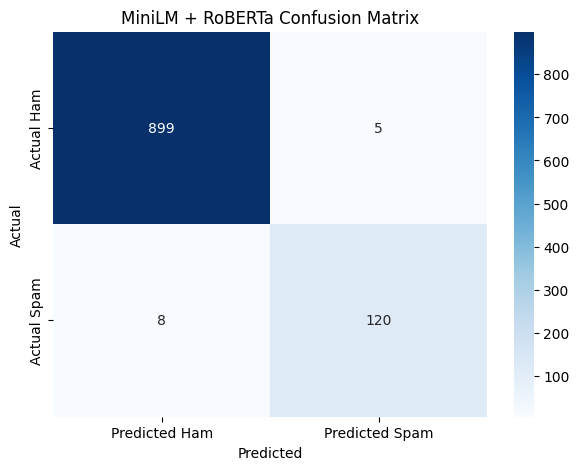

In [ ]:
# Confusion Matrix Graph
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Ham",
        "Predicted Spam"
    ],
    yticklabels=[
        "Actual Ham",
        "Actual Spam"
    ]
)

plt.title(
    "MiniLM + RoBERTa Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# Classification Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Ham",
            "Spam"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       904
        Spam       0.96      0.94      0.95       128

    accuracy                           0.99      1032
   macro avg       0.98      0.97      0.97      1032
weighted avg       0.99      0.99      0.99      1032



In [ ]:
# Evaluation Table
evaluation_table = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation_table

,Metric,Score
0,Accuracy,0.987403
1,Precision,0.960000
2,Recall,0.937500
3,F1-score,0.948617


In [ ]:
# Find Incorrect Predictions
error_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Total incorrect predictions:",
    len(error_indices)
)

Total incorrect predictions: 13


In [ ]:
# Error Analysis
error_data = []

for idx in error_indices:

    actual = int(
        y_true[idx]
    )

    predicted = int(
        y_pred[idx]
    )

    probability = float(
        y_probability[idx]
    )

    if predicted == 1:

        confidence = probability

    else:

        confidence = 1 - probability

    actual_label = (
        "Spam"
        if actual == 1
        else "Ham"
    )

    predicted_label = (
        "Spam"
        if predicted == 1
        else "Ham"
    )

    error_data.append({

        "SMS Text":
            X_test[idx],

        "Actual Label":
            actual_label,

        "Predicted Label":
            predicted_label,

        "Confidence":
            confidence
    })

error_df = pd.DataFrame(
    error_data
)

error_df.head(10)

,SMS Text,Actual Label,Predicted Label,Confidence
0,"sms. ac jsco: energy is high, but u may not kn...",Spam,Ham,0.776335
1,babe: u want me dont u baby! im nasty and have...,Spam,Ham,0.889217
2,your bill at 3 is å£33.65 so thats not bad!,Ham,Spam,0.985167
3,double eviction this week - spiral and michael...,Ham,Spam,0.508740
4,"camera quite good, 10.1mega pixels, 3optical a...",Ham,Spam,0.537884
5,adult 18 content your video will be with you s...,Spam,Ham,0.502921
6,thesmszone.com lets you send free anonymous an...,Spam,Ham,0.742737
7,dating:i have had two of these. only started a...,Spam,Ham,0.791684
8,guess who am i?this is the first time i create...,Spam,Ham,0.554607
9,welcome! please reply with your age and gender...,Spam,Ham,0.707658


In [ ]:
# Error Reason Function
def find_error_reason(text):

    text_lower = text.lower()

    if (
        "http" in text_lower
        or "www" in text_lower
        or ".com" in text_lower
    ):

        return "URL"

    if re.search(
        r"\d+",
        text_lower
    ):

        return "Numbers"

    if len(
        text.split()
    ) <= 4:

        return "Short message"

    if len(
        text.split()
    ) >= 30:

        return "Long message"

    promotional_words = [

        "free",
        "win",
        "winner",
        "prize",
        "offer",
        "claim",
        "cash",
        "urgent",
        "bonus"

    ]

    if any(
        word in text_lower
        for word in promotional_words
    ):

        return "Promotional language"

    return "Informal or ambiguous wording"

In [ ]:
# Add Error Reason
error_df[
    "Possible Reason"
] = error_df[
    "SMS Text"
].apply(
    find_error_reason
)

error_df.head(10)

,SMS Text,Actual Label,Predicted Label,Confidence,Possible Reason
0,"sms. ac jsco: energy is high, but u may not kn...",Spam,Ham,0.776335,Numbers
1,babe: u want me dont u baby! im nasty and have...,Spam,Ham,0.889217,Numbers
2,your bill at 3 is å£33.65 so thats not bad!,Ham,Spam,0.985167,Numbers
3,double eviction this week - spiral and michael...,Ham,Spam,0.508740,Informal or ambiguous wording
4,"camera quite good, 10.1mega pixels, 3optical a...",Ham,Spam,0.537884,Numbers
5,adult 18 content your video will be with you s...,Spam,Ham,0.502921,Numbers
6,thesmszone.com lets you send free anonymous an...,Spam,Ham,0.742737,URL
7,dating:i have had two of these. only started a...,Spam,Ham,0.791684,Informal or ambiguous wording
8,guess who am i?this is the first time i create...,Spam,Ham,0.554607,URL
9,welcome! please reply with your age and gender...,Spam,Ham,0.707658,Numbers


In [ ]:
def predict_sms(text):

    model.eval()

    cleaned_text = clean_text(
        text
    )

    # MiniLM
    minilm_encoding = (
        minilm_tokenizer(
            cleaned_text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
    )

    # RoBERTa
    roberta_encoding = (
        roberta_tokenizer(
            cleaned_text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
    )

    with torch.no_grad():

        output = model(

            minilm_encoding[
                "input_ids"
            ].to(device),

            minilm_encoding[
                "attention_mask"
            ].to(device),

            roberta_encoding[
                "input_ids"
            ].to(device),

            roberta_encoding[
                "attention_mask"
            ].to(device)
        )

        probability = torch.sigmoid(
            output
        ).item()

    if probability >= 0.5:

        prediction = "SPAM"

        confidence = probability

    else:

        prediction = "HAM"

        confidence = 1 - probability

    return (
        prediction,
        confidence
    )

In [ ]:
sms = (
    "Congratulations! You have won "
    "a free iPhone. Click here now!"
)

prediction, confidence = predict_sms(
    sms
)

print(
    "SMS:",
    sms
)

print(
    "Prediction:",
    prediction
)

print(
    f"Confidence: "
    f"{confidence * 100:.2f}%"
)

SMS: Congratulations! You have won a free iPhone. Click here now!
Prediction: SPAM
Confidence: 77.42%


In [ ]:
manual_sms = [

    (
        "Hey, are we still meeting "
        "for lunch at 2 pm today?",
        "HAM"
    ),

    (
        "Please send me the project "
        "report when you reach home.",
        "HAM"
    ),

    (
        "Congratulations! You have won "
        "a free iPhone. Claim it now!",
        "SPAM"
    ),

    (
        "URGENT! You have won a cash "
        "prize of $5000. Call now.",
        "SPAM"
    ),

    (
        "You have been selected for a "
        "special reward. Check your account.",
        "AMBIGUOUS"
    )
]

In [ ]:
manual_results = []

for sms, expected in manual_sms:

    prediction, confidence = (
        predict_sms(sms)
    )

    manual_results.append({

        "SMS":
            sms,

        "Actual/Expected Class":
            expected,

        "Predicted Class":
            prediction,

        "Confidence":
            f"{confidence * 100:.2f}%"
    })

manual_results_df = pd.DataFrame(
    manual_results
)

manual_results_df

,SMS,Actual/Expected Class,Predicted Class,Confidence
0,"Hey, are we still meeting for lunch at 2 pm to...",HAM,HAM,97.88%
1,Please send me the project report when you rea...,HAM,HAM,99.32%
2,Congratulations! You have won a free iPhone. C...,SPAM,SPAM,64.28%
3,URGENT! You have won a cash prize of $5000. Ca...,SPAM,SPAM,98.55%
4,You have been selected for a special reward. C...,AMBIGUOUS,SPAM,61.97%


Test Accuracy: 98.74%
The final training accuracy is 98.67%.



